# Part 1

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from astropy.table import Table

In [13]:
data = Table.read("Planet_Lightcurve.fits")
print(data.colnames)
print(data)

['time [days]', 'flux']
    time [days]             flux       
-------------------- ------------------
                -0.3 0.9718556446853187
 -0.2993993993993994  0.974430548606305
 -0.2987987987987988 0.9696244442016453
 -0.2981981981981982 0.9672472927361904
 -0.2975975975975976 0.9739989623419928
  -0.296996996996997 0.9689265223770298
-0.29639639639639637 0.9678268042192515
 -0.2957957957957958 0.9676453996308826
-0.29519519519519516 0.9703558446606856
 -0.2945945945945946 0.9738800653806102
                 ...                ...
  0.2945945945945945 0.9914653112446374
 0.29519519519519516 0.9978371225844164
  0.2957957957957958  1.000796759382211
  0.2963963963963964 0.9968976911446861
 0.29699699699699694 1.0017105738372651
  0.2975975975975976 1.0025198411286196
  0.2981981981981982 0.9930781407930032
 0.29879879879879884 0.9969834224859118
 0.29939939939939936 0.9998456765152839
                 0.3 0.9997001308741668
Length = 1000 rows


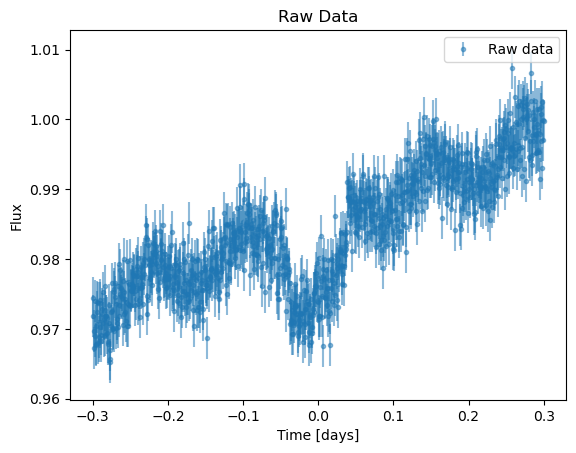

In [14]:
flux = data['flux']
time = data['time [days]']
x_data = np.array(time, dtype=float)
y_data = np.array(flux, dtype=float)
y_err = 0.003
plt.errorbar(x_data, y_data, yerr=y_err,label='Raw data', fmt='.', alpha=0.5)
plt.xlabel("Time [days]")
plt.ylabel("Flux")
plt.title("Raw Data")
plt.legend()
plt.show()

# Part 2 (Ariana Clarey)

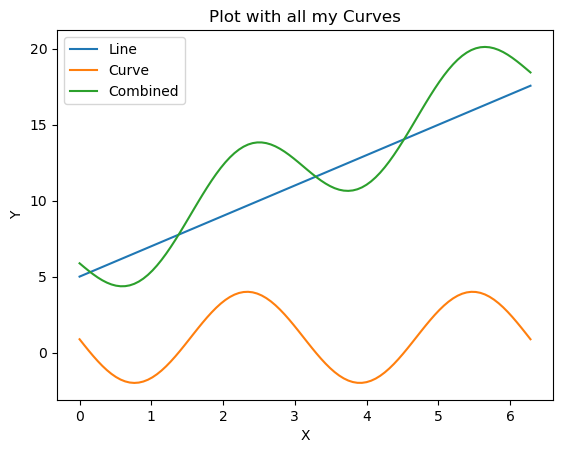

In [15]:
def line(x, m, b):
    return m*x+b

def curve(x, a, p, ph):
    '''
    Inputs:
            a = amplitude (vertical stretch)
            p = period ()
            ph = Phase shift (mode left and right)
    Returns:
    '''
    return ((a*np.sin(p*(x-ph)))+1)
x = np.linspace(0, 2*np.pi, 100)
m = 2
b = 5
a = 3
p = 2
ph = 1.55
y_line = line(x, m, b)
y_curve = curve(x, a, p, ph)

y_correct = y_line+y_curve
plt.plot(x, y_line, label = 'Line')
plt.plot(x, y_curve, label = 'Curve')
plt.plot(x, y_correct, label = 'Combined')
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Plot with all my Curves")
plt.legend()

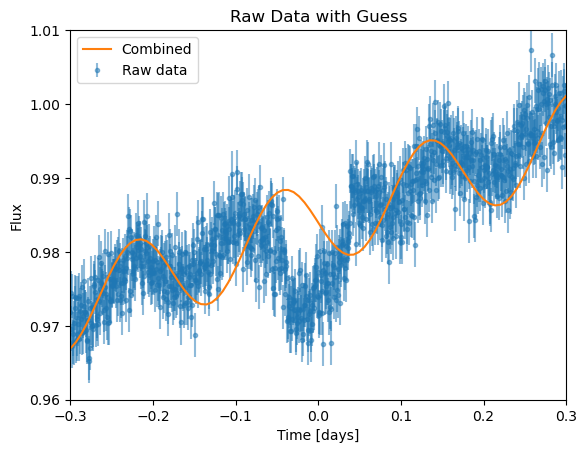

In [16]:
flux = data['flux']
time = data['time [days]']
x_data = np.array(time, dtype=float)
y_data = np.array(flux, dtype=float)
y_err = 0.003


def line(x, m, b):
    return m*x+b

def curve(x, a, p, ph):
    '''
    Inputs:
            a = amplitude (vertical stretch)
            p = period ()
            ph = Phase shift (mode left and right)
    Returns:
    '''
    return ((a*np.sin(p*(x-ph)))+1)
x = np.linspace(-0.3, 2*np.pi, 1000)
m = .038
b = -.016
a = 0.006
p = 35.6
ph = 1.5
y_line = line(x, m, b)
y_curve = curve(x, a, p, ph)


y_guess = y_line+y_curve
plt.errorbar(x_data, y_data, yerr= y_err,label='Raw data', fmt='.', zorder=1, alpha=0.5)
plt.xlim(-0.3,0.3)
plt.ylim(0.96, 1.01)
plt.xlabel("Time [days]")
plt.ylabel("Flux")
plt.title("Raw Data with Guess")
plt.plot(x, y_guess, label = 'Combined', zorder=2)
plt.legend()


In [17]:
initial_guesses1 = [.038,0.985]
params, pcov  = curve_fit(line, x_data[ichoose], y_data[ichoose], sigma=y_err, p0=initial_guesses1)
print(params)

[0.04115656 0.98515361]


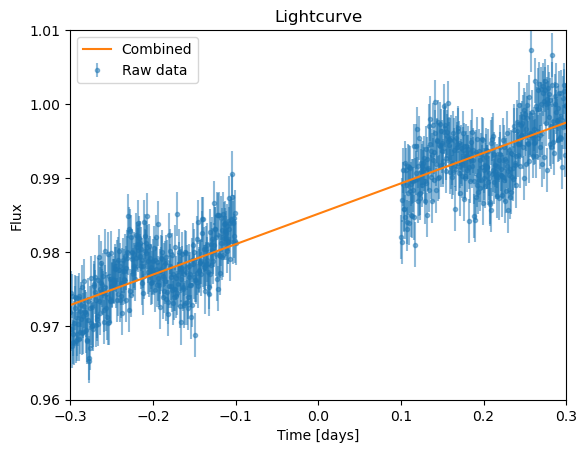

In [18]:
plt.errorbar(x_data[ichoose], y_data[ichoose], yerr= y_err,label='Raw data', fmt='.', zorder=1, alpha=0.5)
plt.xlim(-0.3,0.3)
plt.ylim(0.96, 1.01)
plt.xlabel("Time [days]")
plt.ylabel("Flux")
plt.title("Lightcurve")
plt.plot(x_data, params[0]*x_data+params[1], label = 'Combined', zorder=2)
plt.legend()

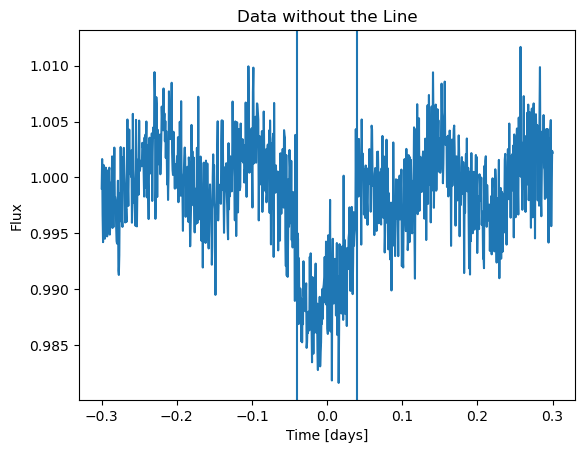

In [19]:
new_y = y_data/(0.041156*x_data+0.98515)
plt.plot(x_data, new_y)
plt.xlabel("Time [days]")
plt.ylabel("Flux")
plt.title("Data without the Line")
plt.axvline(-0.04)
plt.axvline(0.04)


[  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107
 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125
 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143
 144 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161
 162 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179
 180 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197
 198 199 200 201 202 203 204 205 206 207 208 209 210 211 212 213 214 215
 216 217 218 219 220 221 222 223 224 225 226 227 228 229 230 231 232 233
 234 235 236 237 238 239 240 241 242 243 244 245 24

Text(0.5, 1.0, 'Data without the Line')

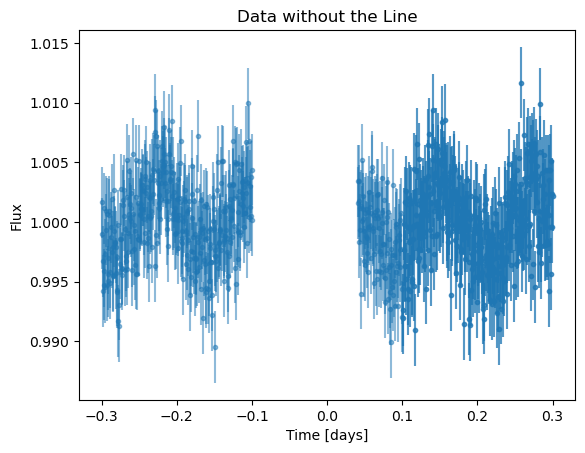

In [20]:
ichoose2 = np.where((np.asarray(x_data) <= -0.04))[0]
ichoose2 = np.append(ichoose, np.where((np.asarray(x_data) >= 0.04))[0])
print(ichoose)
plt.errorbar(x_data[ichoose2], new_y[ichoose2], yerr= y_err,label='Raw data', fmt='.', zorder=1, alpha=0.5)
plt.xlabel("Time [days]")
plt.ylabel("Flux")
plt.title("Data without the Line")

In [21]:
initial_guesses2 = [0.006,50, 1.5]
params2, pcov2 = curve_fit(curve, x_data[ichoose], new_y[ichoose], sigma=y_err, p0=initial_guesses2)
print(params2)

[2.73509033e-03 5.04042031e+01 1.49086917e+00]


Text(0.5, 1.0, 'Data Curve fit to Curve')

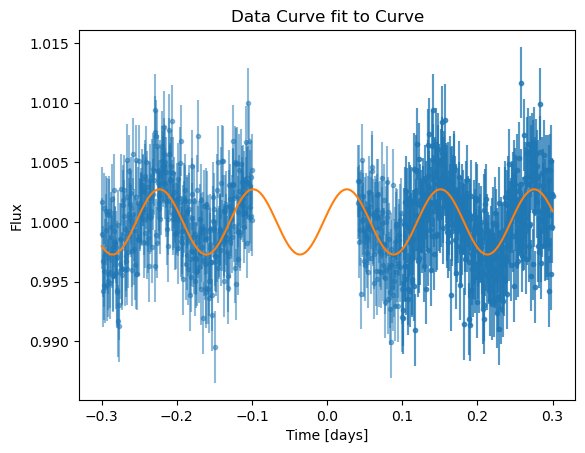

In [22]:
a = params2[0]
p = params2[1]
ph = params2[2]
plt.errorbar(x_data[ichoose2], new_y[ichoose2], yerr= y_err, label='Raw data', fmt='.', zorder=1, alpha=0.5)
y_curve = curve(x_data, a, p, ph)
plt.plot(x_data, y_curve, label = 'Curve', zorder=2)
plt.xlabel("Time [days]")
plt.ylabel("Flux")
plt.title("Data Curve fit to Curve")

Text(0.5, 1.0, 'Final Graph')

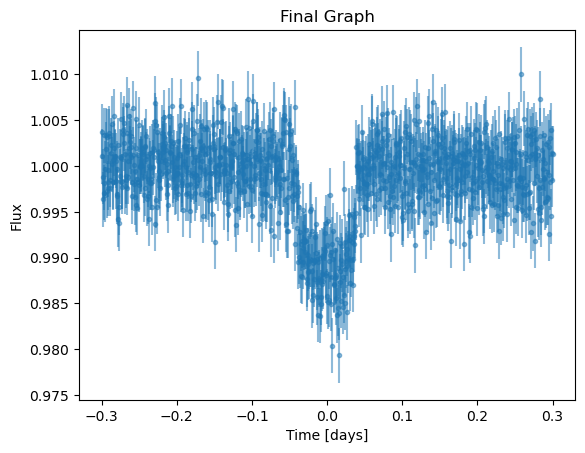

In [23]:
y_best = new_y/y_curve
plt.errorbar(x_data, y_best, yerr=y_err, label='Final Graph', fmt='.', zorder=1, alpha=0.5)
plt.xlabel("Time [days]")
plt.ylabel("Flux")
plt.title("Final Graph")

In [24]:
perr1 = np.sqrt(np.diag(pcov))
perr2 = np.sqrt(np.diag(pcov2))
print(perr1,
     perr2)

[0.00065826 0.00013714] [1.64428855e-04 3.01632075e-01 8.97409244e-03]


# Part 3 (Leying Yang)

In [42]:
clean_flux = y_best

flux = data['flux']
time = data['time [days]']
x = time
y = flux

In [43]:
#Smooth the cleaned light curve using a moving median
from scipy.ndimage import median_filter
window = 31
smooth_flux = median_filter(
    clean_flux,
    size=window,
    mode='nearest'
)

In [44]:
#Assume transit is near the middle of the dataset.
#Exclude central 20% when estimating baseline.

N = len(clean_flux)

exclude_start = int(0.40 * N)
exclude_end   = int(0.60 * N)

out_of_transit = np.concatenate([
    clean_flux[:exclude_start],
    clean_flux[exclude_end:]
])

baseline_flux = np.median(out_of_transit)

print(f"Baseline flux = {baseline_flux:.6f}")

Baseline flux = 1.000036


In [45]:
#Find significant departures from baseline

sigma_flux = 0.003
threshold = baseline_flux - 2*sigma_flux
transit_mask = smooth_flux < threshold
indices = np.where(transit_mask)[0]
groups = np.split(
    indices,
    np.where(np.diff(indices) > 1)[0] + 1
)

transit_group = max(groups, key=len)

start_idx = transit_group[0]
end_idx = transit_group[-1]

t_start = time[start_idx]
t_end = time[end_idx]

duration = t_end - t_start

print(f"Transit start = {t_start:.6f} days")
print(f"Transit end   = {t_end:.6f} days")
print(f"Duration      = {duration:.6f} days")


Transit start = -0.038138 days
Transit end   = 0.036336 days
Duration      = 0.074474 days


In [46]:
#Determining transit depth

inside_transit = (
    (time >= t_start)
    &
    (time <= t_end)
)

transit_flux = np.median(
    clean_flux[inside_transit]
)

depth = baseline_flux - transit_flux

print(f"Transit flux level = {transit_flux:.6f}")
print(f"Transit depth      = {depth:.6f}")

Transit flux level = 0.989666
Transit depth      = 0.010370


In [47]:
#Planet radius

R_star = 1.0
R_planet = np.sqrt(depth) * R_star
Rsun_to_Rearth = 109.1
R_planet_earth = R_planet * Rsun_to_Rearth

print(f"Planet radius = {R_planet:.6f} R_sun")
print(f"Planet radius = {R_planet_earth:.2f} R_earth")

Planet radius = 0.101832 R_sun
Planet radius = 11.11 R_earth


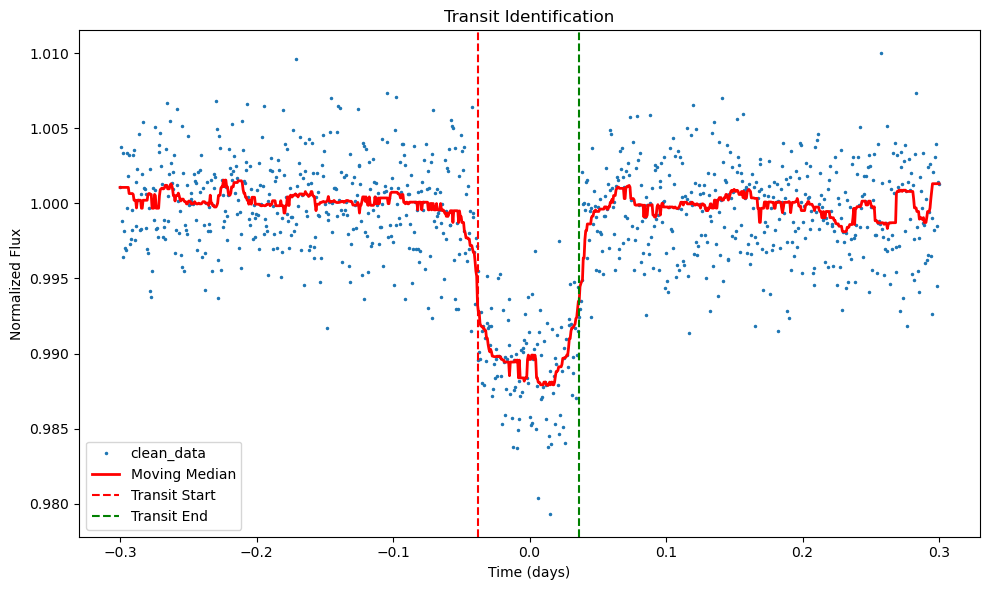

In [48]:
# Plot transit region
plt.figure(figsize=(10,6))
plt.plot(time, clean_flux, '.', ms=3, label='clean_data')
plt.plot(time, smooth_flux,'r',lw=2,label='Moving Median')
plt.axvline(t_start, color='r', ls='--',
            label='Transit Start')
plt.axvline(t_end, color='g', ls='--',
            label='Transit End')
plt.xlabel("Time (days)")
plt.ylabel("Normalized Flux")
plt.title("Transit Identification")
plt.legend()
plt.tight_layout()
plt.savefig("transit_region.pdf")
plt.show()

In [49]:
#uncertainty of transit boundaries
dt = np.median(np.diff(time))

sigma_t_start = dt/2
sigma_t_end = dt/2

print(f"t_start = {t_start:.6f} ± {sigma_t_start:.6f} days")
print(f"t_end   = {t_end:.6f} ± {sigma_t_end:.6f} days")

t_start = -0.038138 ± 0.000300 days
t_end   = 0.036336 ± 0.000300 days


# Part 4 (Momoka Kume)

In [57]:
'''
found in part 2:
------------------
params, pcov
params2, pcov2

line_fit

new_y = y/line_fit

curve_fit

y_best = new_y/curve_fit

'''
flux = data['flux']
time = data['time [days]']

x = time
y = flux

y_err = 0.003

m_fit = params[0]
b_fit = params[1]
a_fit = params2[0]
p_fit = params2[1]
ph_fit = params2[2]

params_err1 = np.sqrt(np.diag(pcov))
params_err2 = np.sqrt(np.diag(pcov2))

m_sigma = params_err1[0]
b_sigma = params_err1[1]

a_sigma = params_err2[0]
p_sigma = params_err2[1]
ph_sigma = params_err2[2]

line_fit = line(x, m_fit, b_fit)
curve_fit = curve(x,a_fit, p_fit, ph_fit)


detrended_flux = y_best

In [58]:
# line: mx + b

m_deriv = x
b_deriv = 1

line_fit_sigma = np.sqrt((m_deriv * m_sigma)**2 + (b_deriv * b_sigma)**2)

data_line_sigma = Table([x, line_fit, line_fit_sigma], names=['time[days]', 'line-fit', 'sigma of line-fit' ])  

print(data_line_sigma)


     time[days]           line-fit        sigma of line-fit   
-------------------- ------------------ ----------------------
                -0.3 0.9728066450766107 0.00024042421221624294
 -0.2993993993993994 0.9728313637319729 0.00024009959107421666
 -0.2987987987987988 0.9728560823873349 0.00023977518230581296
 -0.2981981981981982 0.9728808010426969  0.0002394509867742047
 -0.2975975975975976  0.972905519698059 0.00023912700534667683
  -0.296996996996997 0.9729302383534211  0.0002388032388946465
-0.29639639639639637 0.9729549570087832 0.00023847968829368327
 -0.2957957957957958 0.9729796756641452 0.00023815635442352953
-0.29519519519519516 0.9730043943195074 0.00023783323816812068
 -0.2945945945945946 0.9730291129748694 0.00023751034041560585
                 ...                ...                    ...
  0.2945945945945945 0.9972781138850633 0.00023751034041560583
 0.29519519519519516 0.9973028325404253 0.00023783323816812068
  0.2957957957957958 0.9973275511957874 0.0002381563544

## error of flux without linear artifact (new_y_sigma)

In [59]:
#divide out the linear artifacts
#new_y = y/line_fit

new_y_sigma = (new_y) * np.sqrt(((y_err/y)**2) + (line_fit_sigma/line_fit)**2)

data_new_y_sigma = Table([x,new_y, new_y_sigma], names=['time[days]', 'flux w/o line ', 'sigma of flux w/o line' ]) 
print(data_new_y_sigma)

     time[days]        flux w/o line    sigma of flux w/o line
-------------------- ------------------ ----------------------
                -0.3 0.9990259537441064  0.0030937395979481162
 -0.2993993993993994  1.001647393395902  0.0030936860352267755
 -0.2987987987987988 0.9966817251519697  0.0030934833331302362
 -0.2981981981981982  0.994212978449863  0.0030933302539046803
 -0.2975975975975976 1.0011274403651225  0.0030933602122466116
  -0.296996996996997 0.9958884170431592  0.0030931532540670356
-0.29639639639639637 0.9947328251835151  0.0030930261765001084
 -0.2957957957957958 0.9945211111611093  0.0030929174794743107
-0.29519519519519516  0.997281501220272  0.0030928660366910323
 -0.2945945945945946  1.000878086310153  0.0030928306239877234
                 ...                ...                    ...
  0.2945945945945945  0.994175099382548   0.003017502933204447
 0.29519519519519516 1.0005395263628294  0.0030175730509390654
  0.2957957957957958 1.0034823070588894   0.00301757963

## error of curve-fit line (curve_fit_sigma)

In [60]:
# curve: asin(p(x-ph))+1

a_deriv = np.sin(p_fit*(x-ph_fit))
p_deriv = (x-ph_fit)*a*np.cos(p_fit*(x-ph_fit))
ph_deriv = -p_fit*a*np.cos(p_fit*(x-ph_fit))

curve_fit_sigma = np.sqrt((a_deriv * a_sigma)**2 + (p_deriv * p_sigma)**2 + (ph_deriv * ph_sigma)**2)

data_curve_fit_sigma = Table([x, curve_fit, curve_fit_sigma], names=['time[days]', 'curve-fit', 'sigma of curve-fit' ])  

print(data_curve_fit_sigma)

     time[days]          curve-fit        sigma of curve-fit 
-------------------- ------------------ ---------------------
                -0.3 0.9979654284358019 0.0012936613731494438
 -0.2993993993993994 0.9979110332988143  0.001249966868863824
 -0.2987987987987988 0.9978585524326486 0.0012051918997583574
 -0.2981981981981982 0.9978080339293072 0.0011593833920870858
 -0.2975975975975976 0.9977595240825373 0.0011125902350210249
  -0.296996996996997 0.9977130673454097  0.001064863492229918
-0.29639639639639637 0.9976687062895824  0.001016256692569475
 -0.2957957957957958 0.9976264815662899 0.0009668262310150064
-0.29519519519519516 0.9975864318690907 0.0009166319255046513
 -0.2945945945945946 0.9975485938984106 0.0008657377979047203
                 ...                ...                   ...
  0.2945945945945945 1.0015601263458882 0.0013032538238557689
 0.29519519519519516 1.0014914143231404 0.0013293708889300484
  0.2957957957957958 1.0014213356099035 0.0013542859250353506
  0.2963

## error of detrended_flux (detrended_flux_sigma)

In [61]:
#divide out the curve artifacts
#detrended_flux = new_y/curve_fit

detrended_flux_sigma = (detrended_flux) * np.sqrt((new_y_sigma/new_y)**2 + (curve_fit_sigma/curve_fit)**2)

data_detrended_flux_sigma = Table([x,detrended_flux, detrended_flux_sigma], names=['time[days]', 'detrended flux', 'sigma of detrended flux' ])  

print(data_detrended_flux_sigma)

     time[days]        detrended flux   sigma of detrended flux
-------------------- ------------------ -----------------------
                -0.3 1.0010626874219146    0.003360692557439746
 -0.2993993993993994  1.003744181567706   0.0033454060772959596
 -0.2987987987987988 0.9988206471971304    0.003326566795974089
 -0.2981981981981982 0.9963970469697593   0.0033092521629080555
 -0.2975975975975976 1.0033754789619092   0.0032960173814660866
  -0.296996996996997 0.9981711672804835    0.003278183081788628
-0.29639639639639637 0.9970572584991805   0.0032623742296927732
 -0.2957957957957958 0.9968872414049144     0.00324731884910444
-0.29519519519519516 0.9996943315996717    0.003233563380014982
 -0.2945945945945946 1.0033376744071492    0.003220388018091677
                 ...                ...                     ...
  0.2945945945945945 0.9926264766646773   0.0032780001894215645
 0.29519519519519516 0.9990495295848798   0.0032920003745943996
  0.2957957957957958  1.002058046274529 

In [62]:
depth_sigma = np.median(detrended_flux_sigma)
print(f'uncertainty of depth is {depth_sigma:.10f}')

uncertainty of depth is 0.0032771459


## error of transit time (time_sigma)

In [63]:
# trinsit_time = end_time - start_time
'''
from part 3:
-------------
t_start, sigma_t_start
t_end, sigma_t_end
'''

time_sigma = np.sqrt((sigma_t_end)**2 + (sigma_t_start)**2)
print(f'uncertainty of transit time is {time_sigma}')

uncertainty of transit time is 0.00042468875746940013


# Part 5 (Emory Honeycutt)

In [64]:
from scipy.special import erfc

In [65]:
ichoose3 = np.where((np.asarray(x) <= -0.05))[0]
ichoose3 = np.append(ichoose3, np.where((np.asarray(x) >= 0.05))[0])

flux_oot = y_best[ichoose3]

sigma_clean = np.std(flux_oot)
mean_oot = np.mean(flux_oot)

print(f'mean out-of-transit flux: {mean_oot:.6f}')
print(f'std dev of cleaned flux:  {sigma_clean:.6f}')

mean out-of-transit flux: 0.999877
std dev of cleaned flux:  0.003034


In [66]:
# a 10% solar flare 
flare_flux = mean_oot * 1.10
flare_deviation = flare_flux - mean_oot
N_sigma = flare_deviation / sigma_clean

print(f'flare value:       {flare_flux:.6f}')
print(f'flare deviation:   {flare_deviation:.6f}')
print(f'N-sigma:           {N_sigma:.2f}')

flare value:       1.099865
flare deviation:   0.099988
N-sigma:           32.95


In [67]:
# inject a single 10% outlier 
flare_idx = np.argmin(np.abs(x - 0.15))  # pick a point at t=0.15 days

x_flare = x.copy()
y_flare = y_best.copy()
y_flare[flare_idx] = flare_flux

print(f'flare injected at t = {x_flare[flare_idx]:.4f} days')

flare injected at t = 0.1498 days


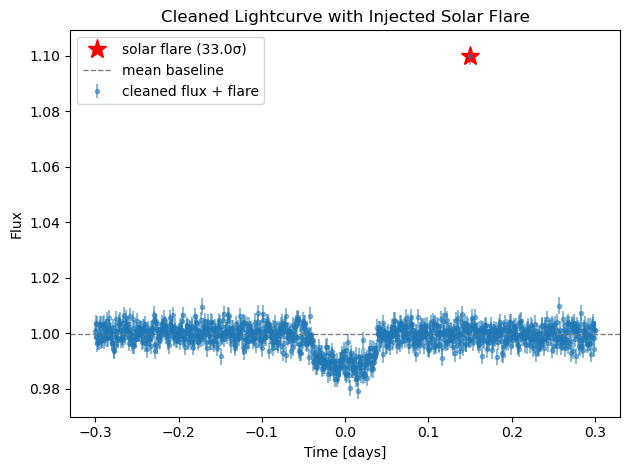

In [68]:
plt.errorbar(x_flare, y_flare, yerr=y_err, fmt='.', alpha=0.5, label='cleaned flux + flare')
plt.plot(x_flare[flare_idx], y_flare[flare_idx], 'r*', ms=14, label=f'solar flare ({N_sigma:.1f}σ)')
plt.axhline(mean_oot, color='gray', ls='--', lw=1, label='mean baseline')
plt.xlabel('Time [days]')
plt.ylabel('Flux')
plt.title('Cleaned Lightcurve with Injected Solar Flare')
plt.legend()
plt.tight_layout()
plt.savefig('flare_lightcurve.pdf')
plt.show()

In [69]:
# Chauvenet's criterion

N_oot = len(flux_oot)
expected = N_oot * erfc(N_sigma / np.sqrt(2))

print(f'N (out-of-transit points): {N_oot}')
print(f'N-sigma:                   {N_sigma:.2f}')
print(f'expected outliers (N*P):   {expected:.2e}')
print()
if expected < 0.5:
    print('expected < 0.5 → significant by Chauvenet criterion')
else:
    print('expected >= 0.5 → not significant by Chauvenet criterion')

N (out-of-transit points): 834
N-sigma:                   32.95
expected outliers (N*P):   3.34e-235

expected < 0.5 → significant by Chauvenet criterion
